# Домашнє завдання: Статистичні візуалізації з Seaborn

## Опис завдання
У цьому домашньому завданні ви будете використовувати бібліотеку Seaborn для створення красивих статистичних візуалізацій. Seaborn має кращий стандартний стиль та спеціалізується на статистичних графіках.

**Опис колонок:**
- `datetime` - дата та час
- `season` - сезон (1=весна, 2=літо, 3=осінь, 4=зима)
- `holiday` - чи є день святковим (0=ні, 1=так)
- `workingday` - чи є день робочим (0=ні, 1=так)
- `weather` - погодні умови (1=ясно, 2=туман, 3=легкий дощ, 4=сильний дощ)
- `temp` - температура в градусах Цельсія
- `atemp` - як відчувається температура
- `humidity` - вологість (%)
- `windspeed` - швидкість вітру
- `casual` - кількість випадкових користувачів
- `registered` - кількість зареєстрованих користувачів
- `count` - загальна кількість орендованих велосипедів

## Підготовка даних


In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Завантаження даних
df = pd.read_csv(r'D:\Навчання\Data Analytics\КУРС DATA ANALIST\python\DATA\yulu_rental.csv')
df['datetime'] = pd.to_datetime(df['datetime'])
df.set_index('datetime', inplace=True)

# Встановлюємо стиль seaborn
sns.set_theme(style="whitegrid")

# Додамо додаткові колонки для аналізу
df['date'] = df.index.date
df['day'] = df.index.day
df['week'] = df.index.isocalendar().week
df['weekday_num'] = df.index.weekday
df['weekday'] = df.index.day_name()
df['year'] = df.index.year
df['month'] = df.index.month
df['hour'] = df.index.hour


---

## Завдання 1: Лінійний графік з довірчими інтервалами

**Завдання:**
Побудуйте лінійний графік середньої кількості оренд помісячно з довірчими інтервалами (confidence intervals) рівними 1 стандартному відхиленню.

**УВАГА!** В лекції ми будували подібний графік, але там були дані по номеру місяця, а тут треба зобразити дані в розрізі місяць_рік.

В якості підказки вам наведений код для створення колонки, яка містить `місяць_рік`. Як її використати - вже питання до вас :)

Очікуваний результат:
![](https://drive.google.com/uc?id=1uVKqfY1VlhVMaM3wu99uVGT1f7S0Vf8S)

**Питання для інтерпретації:**
- В які місяці найбільша невизначеність в даних?

In [2]:
df['month_year'] = df.index.to_period('M')
df['month_year']  = df.month_year.astype(str)

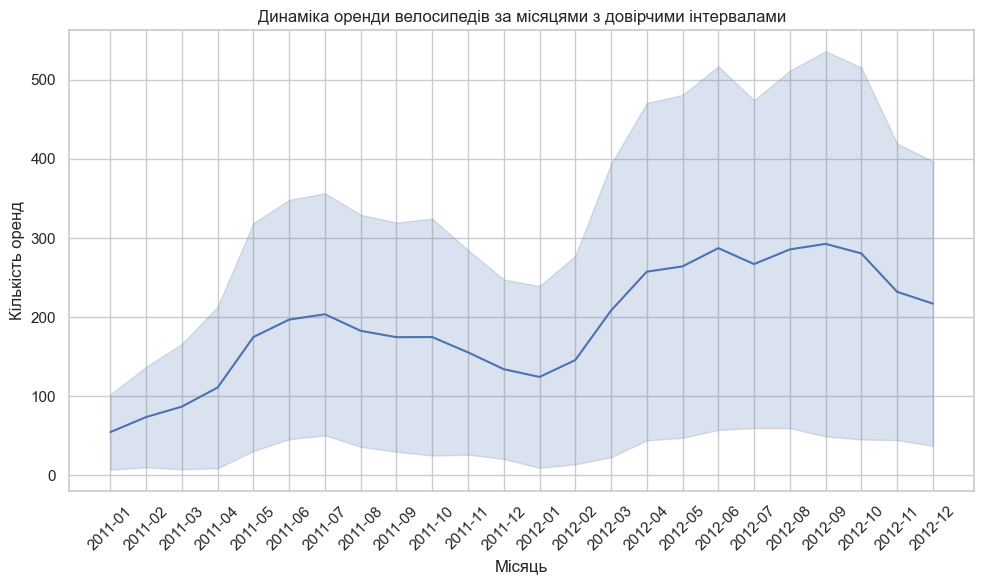

In [3]:
plt.figure(figsize=(10, 6))

sns.lineplot(df, x='month_year', y='count', errorbar='sd')
plt.title('Динаміка оренди велосипедів за місяцями з довірчими інтервалами')
plt.xlabel('Місяць')
plt.ylabel('Кількість оренд')
plt.xticks(rotation=45)
plt.tight_layout();

Найбільша невизначеність в даних спостерігається в період з червня по листопад 2012 року. Тут довірчий інтервал є найширшим. Це свідчить про те, що кількість оренд у ці місяці була нестабільною та сильно варіювалася між днями.

## Завдання 2: Порівняння стилів - Pandas vs Seaborn гістограма

**Завдання:**
Побудуйте гістограму розподілу температури двома способами - з Pandas та Seaborn - та порівняйте візуальний вигляд. Задайте однакову кількість бінів в цих візуалізаціях, відмінну від стандартної. В візуалізації Seaborn додайте параметр при побудові `kde=True`.

**Функція Seaborn: `sns.histplot()`**

Можна побудувати окремо два графіки. Але для тих, хто хоче складніше - побудуйте ці 2 графіки на 1 фігурі.

**Дайте відповідь на питання:**
1. Яка візуальна різниця між Pandas та Seaborn гістограмами?
2. Що за лінія додаткова на графіку в Seaborn? Як вона називається і як ви б її описали своїми словами?

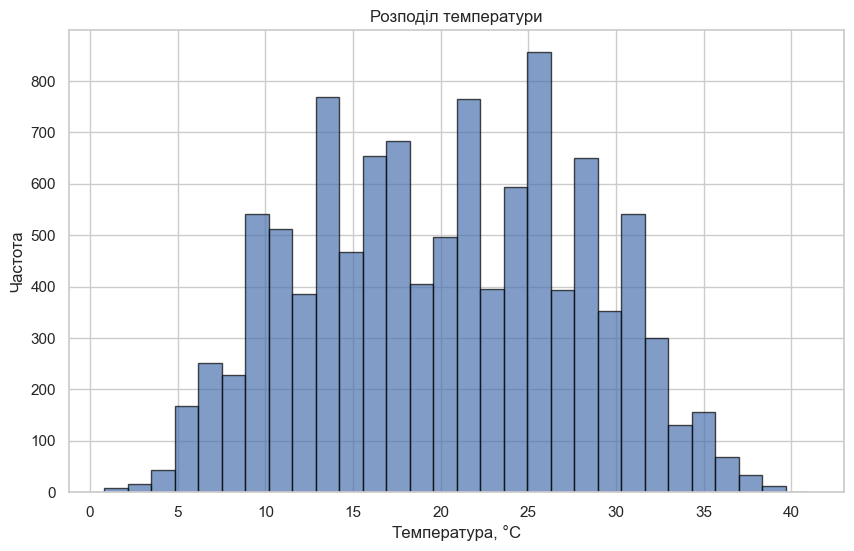

In [4]:
# Гітрограма в Pandas
df['temp'].plot.hist(
    bins=30,
    figsize=(10, 6),
    alpha=0.7,
    edgecolor='black',
    title='Розподіл температури')
plt.xlabel('Температура, °C')
plt.ylabel('Частота')
plt.show()

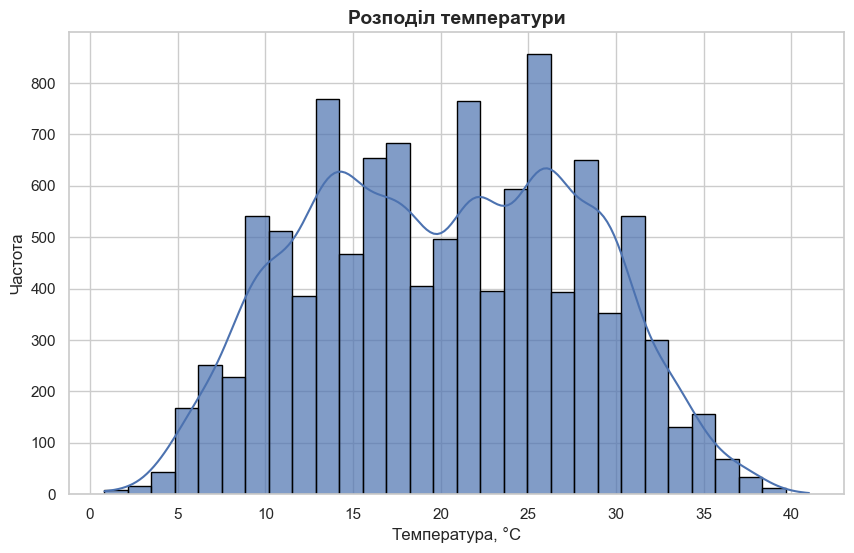

In [5]:
# Гітрограма в Seaborn
plt.figure(figsize=(10,6))
sns.histplot(df, x='temp', bins=30, edgecolor='black', alpha=0.7, kde=True)
plt.title('Розподіл температури', fontsize=14, fontweight='bold')
plt.xlabel('Температура, °C')
plt.ylabel('Частота')
plt.show()

1. Візуально графік побудований в Pandas та Seaborn нічим не відрізнеяється. Відмінністю є додаткова лінія в гістограмі Seaborn

2. На графіку Seaborn додаткова лінія - це крива щільності розподілу. Це плавна лінія, яка приблизно повторює форму гістограми, але робить її м’якшою й зрозумілішою для ока.

## Завдання 3: Box Plot порівняння - Pandas vs Seaborn

**Завдання:**
Побудуйте box plot для кількості погодинних оренд велосипедів за погодними умовами з Pandas та Seaborn.

**Функція Seaborn: `sns.boxplot()`**

Можна побудувати окремо два графіки. Але для тих, хто хоче складніше - побудуйте ці 2 графіки на 1 фігурі.

Просунуте доповнення:
- підпишіть погодні умови їх інтерпретацією з опису даних в обох графіках

**Дайте відповідь на питання:**
- Яка візуальна різниця між Pandas та Seaborn бокс-плотами?

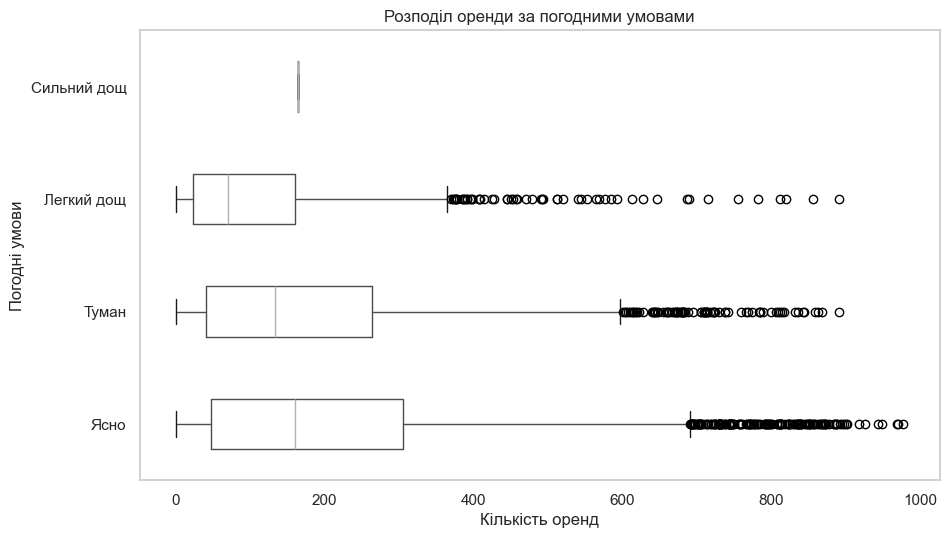

In [6]:
weather_labels = {1: 'Ясно', 2: 'Туман', 3: 'Легкий дощ', 4: 'Сильний дощ'}

ordered_weather = ['Ясно', 'Туман', 'Легкий дощ', 'Сильний дощ']

df['weather_label'] = pd.Categorical(
    df['weather'].map(weather_labels),
    categories=ordered_weather,
    ordered=True
)

df.boxplot(
    column='count',
    by='weather_label',
    figsize=(10, 6),
    vert=False
)
plt.title('Розподіл оренди за погодними умовами')
plt.xlabel('Кількість оренд')
plt.ylabel('Погодні умови')
plt.grid(False)
plt.suptitle('')
plt.show()

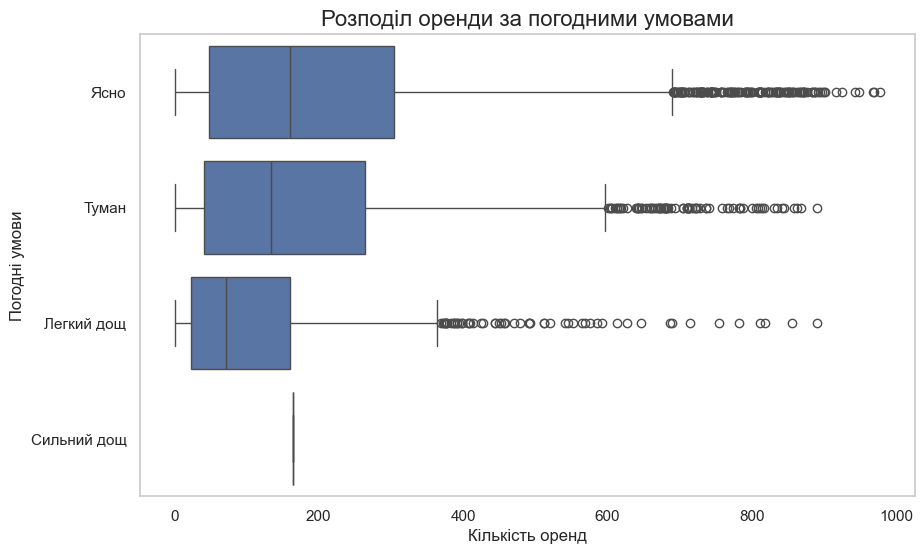

In [7]:
plt.figure(figsize=(10,6))

sns.boxplot(df,x='count', y='weather_label')
plt.title('Розподіл оренди за погодними умовами', fontsize=16)
plt.xlabel('Кількість оренд')
plt.ylabel('Погодні умови')
plt.suptitle('')
plt.grid(False)
plt.show()

Box plot в Seaborn якийсь акуратніший ніж в Рandas, легше сприймається. Одразу є заливка коробочок.

<!-- - -->
## Завдання 4: Heatmap кореляційної матриці

**Завдання:**
Створіть із Seaborn кореляційну матрицю з забарвленням heatmap (колір відповідає величині значення в клітинці) числових змінних в наших даних з анотаціями значень.

**Дайте відповіді на питання по графіку:**
1. Які змінні найсильніше корелюють з загальною кількістю оренди (count)?
2. Яка кореляція між temp та atemp? Чому?
3. Які змінні мають негативну кореляцію?


In [8]:
correlation = df[['temp', 'atemp', 'humidity', 'windspeed', 'casual', 'registered', 'count']].corr()

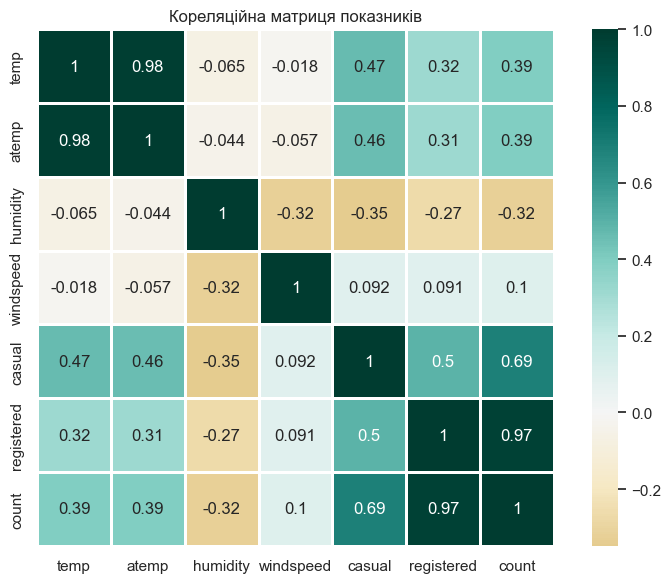

In [9]:
plt.figure(figsize=(8, 6))

sns.heatmap(correlation, annot=True, cmap='BrBG', center=0,
            square=True, linewidths=1
            )
plt.title('Кореляційна матриця показників')
plt.tight_layout()
plt.show()

1. Які змінні найсильніше корелюють з загальною кількістю оренди (count)?
   - registered — 0.98 - дуже висока позитивна кореляціящо є цілком логічним, адже основну частину всіх оренд здійснюють зареєстровані користувачі.
    - casual — 0.69 - також досить висока позитивна кореляція кількості оренд з випадковими користувачами.
    - temp / atemp — по 0.39. Це є помірною позитивною кореляцією — з підвищенням температури кількість оренд зростає.
      
2. Яка кореляція між temp та atemp? Чому?  
Кореляція між temp і atemp — 0.98 Це майже повна позитивна кореляція, тобто вони змінюються майже одночасно. atemp — це те, як температура відчувається і вона тісно пов’язана з фактичною температурою. Зачасту temp ≈ atemp, тому одну з них можна не включати в модель, щоб уникнути плутанини.


4. Які змінні мають негативну кореляцію?  
З count (загальна кількість оренд) негативно корелює humidity(вологість) -0.32. Це означає, що коли вологість висока, люди менше орендують велосипеди. Сильний вітер теж трохи знижує кількість оренд, хоча зв’язок слабкий.  Також humidity і windspeed мають негативну кореляцію з casual, registered, temp, atemp.


## Завдання 5: Violin Plot для глибокого аналізу розподілів

**Завдання:**
Створіть violin plot для аналізу розподілу оренди за сезонами.

Дайте відповіді на питання:

**Питання для інтерпретації:**
1. Що показує "товщина" violin plot?
2. В якому сезоні найбільша варіабельність оренди?
3. Яка перевага violin plot над звичайним box plot?


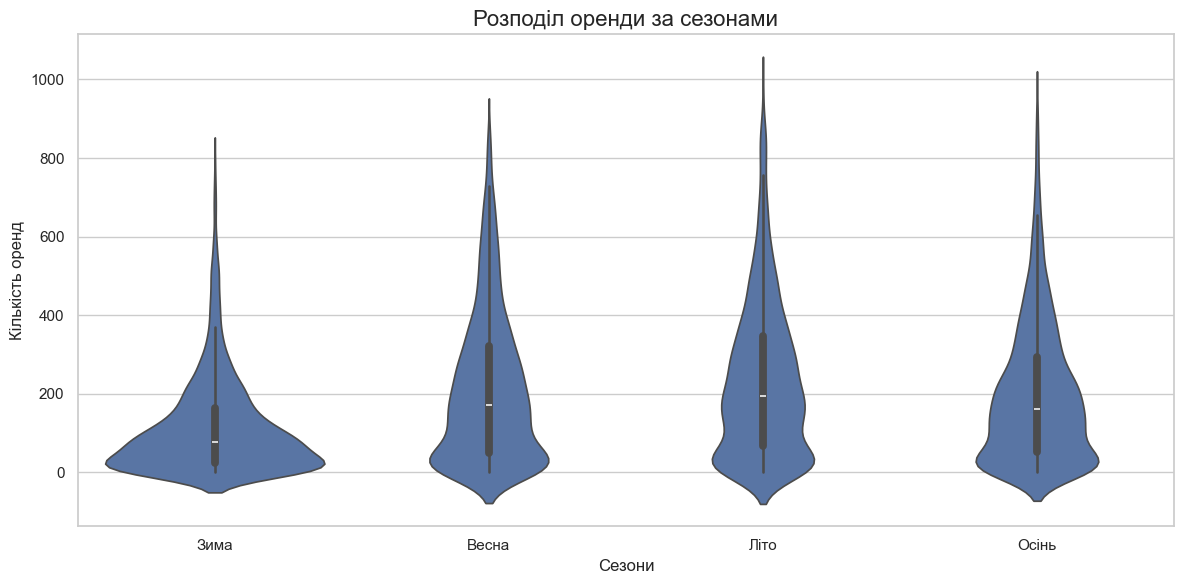

In [14]:
plt.figure(figsize=(12, 6))
sns.violinplot(data=df, x='season', y='count')

plt.title('Розподіл оренди за сезонами', fontsize= 16)
plt.xticks([0, 1, 2, 3], ['Зима', 'Весна', 'Літо', 'Осінь'])
plt.xlabel('Сезони')
plt.ylabel('Кількість оренд')
plt.tight_layout()
plt.show()

1. Що показує "товщина" violin plot?  
Товщина або ширина у violin plot показує щільність розподілу даних на конкретному значенні осі Y.
Чим товще візуалізація в певній точці — тим більше спостережень у цій зоні (частота більша).

2. В якому сезоні найбільша варіабельність оренди?  
Найбільша варіабельність оренди спостерігається влітку. Також досить високі показники маємо восени.

3. Яка перевага violin plot над звичайним box plot?  
Violin plot дає ту ж інформацію, що і Box plot (медіану, квартилі, мінімум і максимум, викиди), але додає повний розподіл даних, показуючи форму щільності. Це допомагає краще розуміти, як саме розподілені дані — чи вони симетричні, чи багатопікові, чи є скупчення на певних значеннях. Тобто violin plot — більш інформативний, бо показує деталі розподілу, які не видно в box plot.

## Завдання 6: Pairplot для мультиваріативного аналізу

**Завдання:**
Створіть pairplot для аналізу взаємозв'язків між ключовими змінними `'temp', 'humidity', 'windspeed', 'count'` . В якості візуальної розбивки за категоріями (параметр `hue`) додайте сезон.

Дайте відповіді на питання:

**Питання для інтерпретації:**
1. Між якими змінними спостерігається найсильніший лінійний зв'язок?
2. Яка характеристика найбільше змінюється від сезону?

In [11]:
season_labels = {1: 'Зима', 2: 'Весна', 3: 'Літо', 4: 'Осінь'}
df['season_label'] = df['season'].map(season_labels)

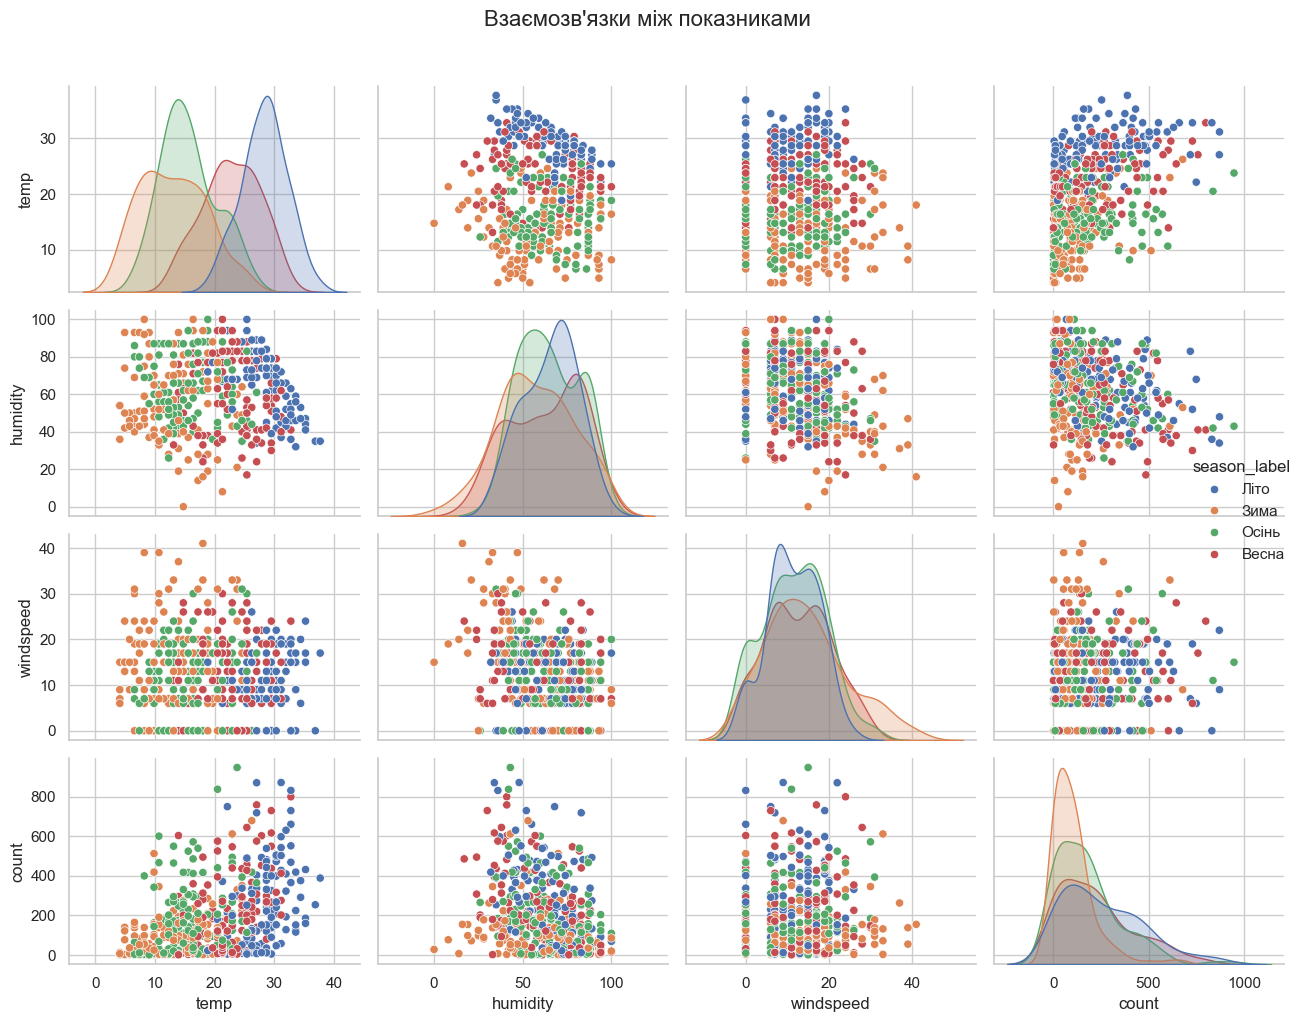

In [12]:
sample_df = df[['temp', 'humidity', 'windspeed', 'count', 'season_label']].sample(500, random_state=42)
sns.pairplot(sample_df, hue='season_label', height=2.5, aspect=1.2,)
plt.suptitle("Взаємозв'язки між показниками", y=1.02, fontsize= 16)
plt.tight_layout()
plt.show()

Найсильніший лінійний зв'язок є між змінними count та temp. Зі збільшенням температури збільшується кількість оренд велосипедів.

На мій погляд, найбільше від сезону змінюється температура, що є логічним.


## Завдання 7: Joint Plot для детального аналізу двох змінних

**Завдання:**
Проаналізуйте залежність між температурою та орендою за допомогою joint plot. В якості візуальної розбивки за категоріями (параметр `hue`) додайте `workingday`.

Дайте відповіді на питання:

**Питання для інтерпретації:**
1. Що показують графіки по краях?
2. Чи є різниця у поведінці користувачів у робочий і неробочий день?

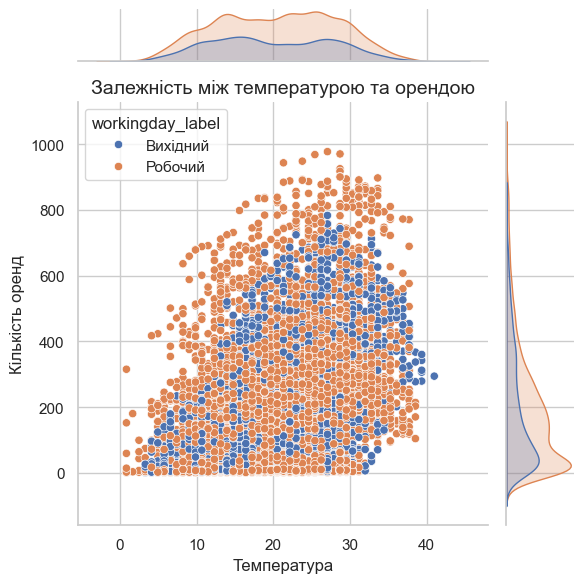

In [22]:
df['workingday_label'] = df['workingday'].map({0: 'Вихідний', 1: 'Робочий'})

sns.jointplot(data=df, x='temp', y='count', hue='workingday_label')

plt.title('Залежність між температурою та орендою', fontsize= 14)
plt.xlabel('Температура')
plt.ylabel('Кількість оренд')
plt.tight_layout()

plt.show()

Графіки по краях показують розподіли окремо для температури (зверху) та кількості оренд (праворуч). Також вони розділені за вихідними і робочими днями.  

Загалом оренд більше у робочі дні, вони менш залежні від температури. Скоріше за все, це пов'язано з тим, що переважають постійні зареєстровані клієнти, що орендують велосипеди для поїздок на роботу чи навчання.